In [1]:
from Common.Core.CustomLayers.Activations.LaplaceS import LaplaceActivationS

In [2]:
import inspect
import torch
import torch.nn as nn
import torch.optim as optim
from Common.Core.Universal.NNFrameWork import NNFrameWork, cpu, gpu
from Common.Core.CustomLayers.Activations.Relpu import RelpuGlob
from d2l import torch as d2l
import matplotlib.pyplot as plt

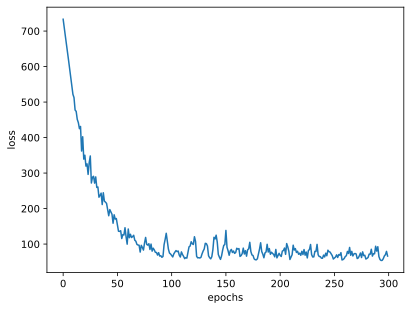

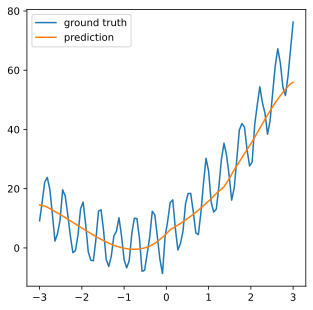

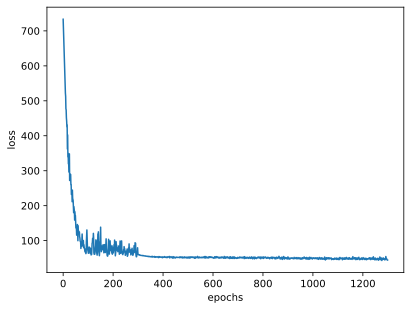

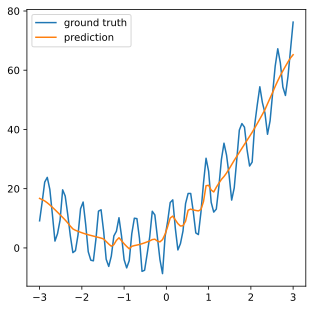

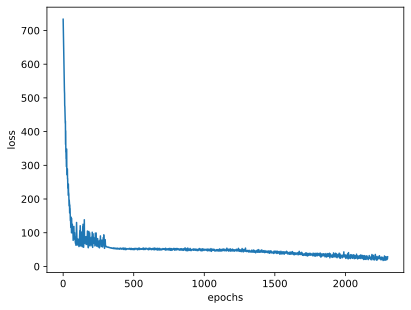

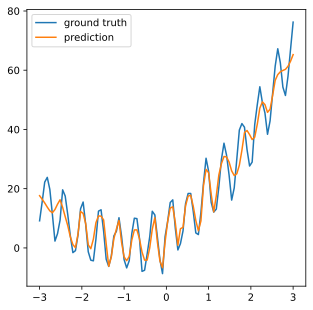

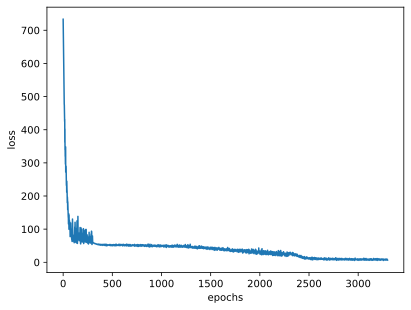

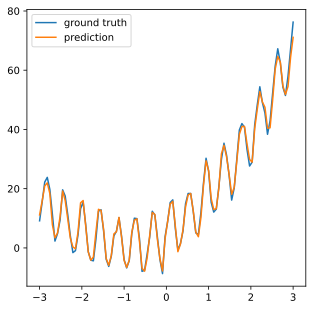

6.741084575653076


In [3]:
class SingleHiddenLayer1d(nn.Module):
    """
    单隐层增量神经网络单元
    """

    def __init__(self, input_size, hidden_size, output_size, activation1, activation2):
        super().__init__()
        self.hidden_size = hidden_size
        self.bn_in = nn.BatchNorm1d(input_size)

        #################################激活函数设置1################################
        if isinstance(activation1(1), RelpuGlob):
            self.a_in = activation1(input_size, u_a=-0.5, u_b=2.0)
        elif 'features' in inspect.signature(activation1).parameters:
            self.a_in = activation1(input_size)
        else:
            self.a_in = activation1()
        #################################激活函数设置1################################

        self.linear1 = nn.Linear(input_size, hidden_size, bias=False)
        self.bn_out = nn.BatchNorm1d(hidden_size)

        #################################激活函数设置2################################
        if isinstance(activation2(1), RelpuGlob):
            self.a_out = activation2(hidden_size, u_a=-0.5, u_b=2.0)
        elif 'features' in inspect.signature(activation2).parameters:
            self.a_out = activation2(hidden_size)
        else:
            self.a_out = activation2()
        #################################激活函数设置2################################

        self.dropout = nn.Dropout(0.5)
        self.linear2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x_in = x
        x = self.bn_in(x)
        x = self.a_in(x)
        x = self.linear1(x)
        mid_out = x
        x = self.bn_out(x)
        x = self.dropout(self.a_out(x))
        x = self.linear2(x)
        return x, torch.cat([x_in, mid_out], dim=1)


class DynaSInit(nn.Module):
    """
    增量神经网络初始化单元
    """

    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.linear1 = nn.Linear(input_size, hidden_size, bias=False)
        self.linear2 = nn.Linear(hidden_size, output_size)
        self.bn = nn.BatchNorm1d(hidden_size)
        self.activation = LaplaceActivationS(hidden_size)

    def forward(self, x):
        middle = self.linear1(x)
        output = self.linear2(self.activation(self.bn(middle)))
        return output, torch.cat([x, middle], dim=1)


class DynamicNN1d(NNFrameWork):
    """
    动态神经网络总体架构v1
    """

    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.input_size = input_size
        self.output_size = output_size
        self.layers = nn.ModuleList()
        self.layers.append(DynaSInit(input_size, hidden_size, output_size))
        self.bandwidth = hidden_size + output_size

    def forward(self, x):
        output = 0
        for layer in self.layers:
            x, hidden_out = layer(x)
            output += x
            x = hidden_out
        return output

    def add_layer(self, hidden_size, activation1, activation2):
        self.layers.append(SingleHiddenLayer1d(self.bandwidth, hidden_size, self.output_size, activation1, activation2))
        self.bandwidth += hidden_size
        self.to(self.device)

    def delete_layer(self, key):
        self.layers.pop(key)
        self.bandwidth -= self.layers[-1].hidden_size

    def set_step_optimizer(self, lr=0.01, momentum=0.0, clip_value=float("inf"), weight_decay=0, optimizer="default"):
        self.clip_value = clip_value
        if optimizer == "default":
            self.optimizer = optim.SGD(self.layers[-1].parameters(), lr=lr, momentum=momentum,
                                       weight_decay=weight_decay)
            # self.optimizer = optim.SGD(self.parameters(), lr=lr, momentum=momentum)
        else:
            self.optimizer = optimizer


def plot_fitting_result(net, x, y):
    """
    用于显示模型的拟合结果
    :param net:
    :param x:
    :param y:
    :return:
    """
    net.set_device(cpu())
    d2l.use_svg_display()
    plt.figure(figsize=(5, 5))
    plt.plot(x.detach().numpy(), y.detach().numpy(), label="ground truth")
    plt.plot(x.detach().numpy(), net.predict(x).to("cpu").detach().numpy(), label="prediction")
    plt.legend()
    plt.show()


def dyna_train(net, a1, a2, hidden_size, data_iter, lr, epochs, x_to_fit, y_to_fit):
    """
    动态训练神经网络
    :param net: 网络
    :param a1: 激活函数1
    :param a2: 激活函数2
    :param hidden_size: 隐藏层数量
    :param data_iter: 数据迭代器
    :param lr: 学习率
    :param epochs: 训练轮数
    :param x_to_fit: 拟合数据x
    :param y_to_fit: 拟合数据y
    :return:
    """
    net.add_layer(hidden_size, a1, a2)
    net.set_step_optimizer(lr=lr)
    net.train_fixed(data_iter, epochs=epochs, plot_hist=True)
    plot_fitting_result(net, x_to_fit, y_to_fit)
    return net.loss_history[-1]


if __name__ == "__main__":
    import torch.utils.data as Data

    # 生成非线性数据
    x = torch.linspace(-3, 3, 100).reshape(-1, 1)
    noise = torch.randn(*x.shape)
    x_outer = torch.linspace(-6, 6, 1000).reshape(-1, 1)
    y = 4.2 * (x + 1) ** 2 + 1.1 + noise + 1 * torch.randn(*x.shape) + 10 * torch.sin(x * 15)
    y_outer = 4.2 * (x_outer + 1) ** 2 + 1.1 + 1 * torch.randn(*x_outer.shape) + 10 * torch.sin(x_outer * 15)
    dataSet = Data.TensorDataset(x, y)
    data_iter = Data.DataLoader(dataSet, batch_size=100, shuffle=True)

    # 初始化动态神经网络
    dyna_nn = DynamicNN1d(1, 10, 1)
    dyna_nn.set_step_optimizer(lr=0.01)
    dyna_nn.set_criterion(nn.MSELoss())
    dyna_nn.set_device(gpu())

    # 动态神经网络初始化单元训练
    dyna_nn.train_fixed(data_iter, epochs=300, plot_hist=True)
    plot_fitting_result(dyna_nn, x, y)

    # 动态神经网络第一次训练
    dyna_train(dyna_nn, LaplaceActivationS, LaplaceActivationS, 10, data_iter, 0.01, 1000, x, y)

    # 动态神经网络第二次训练
    dyna_train(dyna_nn, LaplaceActivationS, LaplaceActivationS, 20, data_iter, 0.01, 1000, x, y)

    # 动态神经网络第三次训练
    loss = dyna_train(dyna_nn, LaplaceActivationS, LaplaceActivationS, 30, data_iter, 0.01, 1000, x, y)
    print(loss)

In [4]:
for name, a in dyna_nn.layers[-2].a_in.snake.named_parameters():
    print(name, a)

a1 Parameter containing:
tensor([-0.0303, -0.0561, -0.2884, -0.1280, -0.2596, -0.2858,  0.0286, -1.2224,
        -0.0360, -0.0629, -0.0483,  0.5972,  0.4463, -0.2673, -0.3346,  0.0961,
        -0.0348,  0.3712, -1.2086,  0.7088,  0.0808], requires_grad=True)
b1 Parameter containing:
tensor([0.9999, 1.0084, 0.9740, 0.9590, 0.9889, 0.9823, 0.9991, 1.1970, 1.0006,
        1.0019, 1.0006, 0.6182, 0.9681, 0.9973, 0.8591, 0.2191, 0.9998, 0.8046,
        1.5931, 0.8216, 1.0033], requires_grad=True)
a2 Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       requires_grad=True)
b2 Parameter containing:
tensor([-1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
        -1., -1., -1., -1., -1., -1., -1.], requires_grad=True)
